# Entrenamiento y Evaluación de Modelos Predictivos de Volatilidad Implícita

**Objetivo**: Evaluar y entrenar múltiples modelos de Machine Learning y Deep Learning (Regresión Lineal, Random Forest, XGBoost, Redes Neuronales Secuenciales y Quantum-Inspired) para predecir la Volatilidad Implícita de opciones del IBEX 35 con mínimo error.

**Flujo** (realizado para cada familia de modelos):
1. Validación cruzada (CV) explorando múltiples configuraciones de hiperparámetros para seleccionar la mejor
2. Reentrenamiento en TRAIN+VAL usando la mejor configuración de parámetros encontrada
3. Evaluación del modelo reentrenado en FINAL_TEST
4. Reentrenamiento progresivo en TRAIN+VAL (priorizando datos ATM) con la mejor configuración de parámetros
5. Evaluación del modelo progresivo en FINAL_TEST

In [1]:
import sys, os

# Walk up from cwd to find the project root (identified by pytest.ini)
_dir = os.getcwd()
while _dir != os.path.dirname(_dir):
    if os.path.exists(os.path.join(_dir, "pytest.ini")):
        break
    _dir = os.path.dirname(_dir)

if _dir not in sys.path:
    sys.path.insert(0, _dir)

print("Project root added to sys.path:", _dir)


Project root added to sys.path: c:\Users\danir\Desktop\TFM - Opciones\options-pricing


In [2]:
from src.volatility_models.data_utils import TrainingDataHandler

from src.volatility_models.training_utils import Trainer
from src.python_models.volatility_models.volatility_model_family import (
    LinearRegressionFamily,
    RandomForestFamily,
    XGBoostFamily,
    SequentialNNFamily,
    QuantumInspiredNNFamily,
)
from src.python_models.volatility_models.volatility_model_family import TrainingPhase

## Preparación: Carga de datos y Splits

In [2]:
# Columnas escogidas para features + target + auditoría
volatility_df = TrainingDataHandler.load_volatility_db()
print("Rows loaded:", len(volatility_df))
display(volatility_df.head())

Rows loaded: 312615


,ExecDatetime,OptionContractCode,OptionType,StrikePrice,UnderlyingPrice,TimeToExpiration,Rate,ImpliedVolatility
0,2017-01-02 09:13:43,CIBX 9600F17,C,9600.0,9305.0,18.344641,-0.500415,0.175113
1,2017-01-02 09:24:08,CIBX 9300F17,C,9300.0,9314.0,18.337408,-0.500612,0.189698
2,2017-01-02 09:32:52,CIBX 9400F17,C,9400.0,9331.0,18.331343,-0.500778,0.185166
3,2017-01-02 09:32:53,CIBX 9400F17,C,9400.0,9335.0,18.331331,-0.500778,0.184247
4,2017-01-02 09:35:09,PIBX 9200F17,P,9200.0,9338.0,18.329758,-0.500821,0.192584


Carga de datos con características computadas (one-hot encoding de variables categóricas ya aplicado).

In [3]:
train_df, val_df, test_df = TrainingDataHandler.load_splitted_data()

2026-05-17 15:38:36,868 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied between trainval and test | overlapping contracts: 44 | removed rows -> trainval: 364, test: 31
2026-05-17 15:38:37,070 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied between train and val | overlapping contracts: 53 | removed rows -> train: 101, val: 107
2026-05-17 15:38:37,129 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-05-17 15:38:37,129 | INFO | src.volatility_models.data_utils | INITIAL TEMPORAL SPLIT (entire dataset): Train / Valid / Test
2026-05-17 15:38:37,129 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-05-17 15:38:37,129 | INFO | src.volatility_models.data_utils | Total rows: 306,857 | Total dates: 1,372
2026-05-17 15:38:37,129 | INFO | src

In [4]:
train_df, val_df, test_df = TrainingDataHandler.load_full_features_splitted_data()
trainval_df, final_test_df = TrainingDataHandler.load_full_features_trainval_test_data()

2026-05-17 15:38:40,297 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied between trainval and test | overlapping contracts: 44 | removed rows -> trainval: 364, test: 31
2026-05-17 15:38:40,540 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied between train and val | overlapping contracts: 53 | removed rows -> train: 101, val: 107
2026-05-17 15:38:40,609 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-05-17 15:38:40,610 | INFO | src.volatility_models.data_utils | INITIAL TEMPORAL SPLIT (entire dataset): Train / Valid / Test
2026-05-17 15:38:40,610 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-05-17 15:38:40,612 | INFO | src.volatility_models.data_utils | Total rows: 306,857 | Total dates: 1,372
2026-05-17 15:38:40,613 | INFO | src

In [5]:
folds = TrainingDataHandler.load_kfolds()

2026-05-17 15:38:53,679 | INFO | src.volatility_models.data_utils | Train/Val/Test split | rows: train=243791 [2017-01-02 -> 2020-11-09]  val=26093 [2020-12-01 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=306857
2026-05-17 15:38:54,499 | INFO | src.volatility_models.data_utils | 
2026-05-17 15:38:54,499 | INFO | src.volatility_models.data_utils | TEMPORAL K-FOLDS (within Train only) for model-family validation
2026-05-17 15:38:54,499 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-05-17 15:38:54,505 | INFO | src.volatility_models.data_utils | Global Train -> rows: 243,791 | dates: 984
2026-05-17 15:38:54,522 | INFO | src.volatility_models.data_utils | FOLD-1
2026-05-17 15:38:54,523 | INFO | src.volatility_models.data_utils |   Fold effective total: 100,976 rows | 342 dates
2026-05-17 15:38:54,525 | INFO | src.volatility_models.data_utils |   TRAIN | rows:   89,613 ( 88.75% o

# Fase 1: Validación Cruzada (CV) explorando múltiples configuraciones de hiperparámetros

2026-05-17 15:38:54,759 | INFO | src.volatility_models.training_utils | Hyperparameter exploration for 'linear_regression' (metadata cache): 1/1 configurations (100.00%).
2026-05-17 15:38:54,760 | INFO | src.volatility_models.visualization_utils | Metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\linear_regression_metadata.json
2026-05-17 15:38:54,763 | INFO | src.volatility_models.visualization_utils | Showing top 15 family models
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
linear_regression       0.097966   0.038728    0.099166  0.247704  0.053389  0.089122 -0.099442        0.00499        0.015623      0.047159     0.032112      0.035374    0.296508


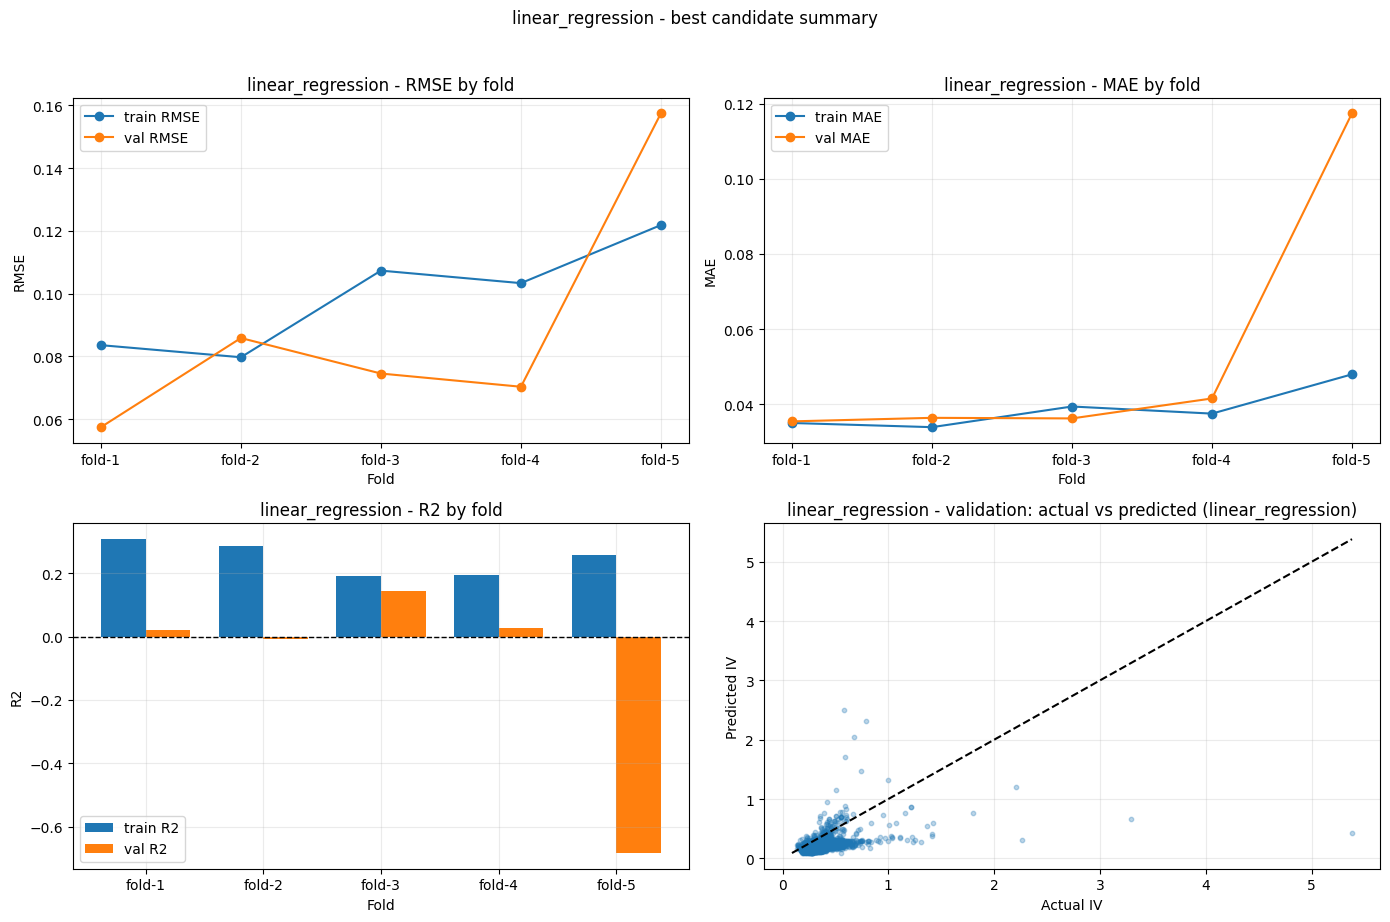

In [6]:
linear_models_metrics_table, linear_best_model_name = Trainer(LinearRegressionFamily).run_kfolds_training()

2026-05-17 15:39:02,229 | INFO | src.volatility_models.training_utils | Hyperparameter exploration for 'random_forest' (metadata cache): 120/46080 configurations (0.26%).
2026-05-17 15:39:02,230 | INFO | src.volatility_models.visualization_utils | Metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\random_forest_metadata.json
2026-05-17 15:39:02,235 | INFO | src.volatility_models.visualization_utils | Showing top 15 family models
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
random_forest_043       0.072964   0.023700    0.044584  0.848682  0.042358  0.055959  0.556924       0.002877        0.009548      0.024734     0.030341      0.033896    0.303422
random_forest_011       0.073454   0.022665    0.041790  0.867241  0.042033  0.054991  0.571183       0.003100        0.0

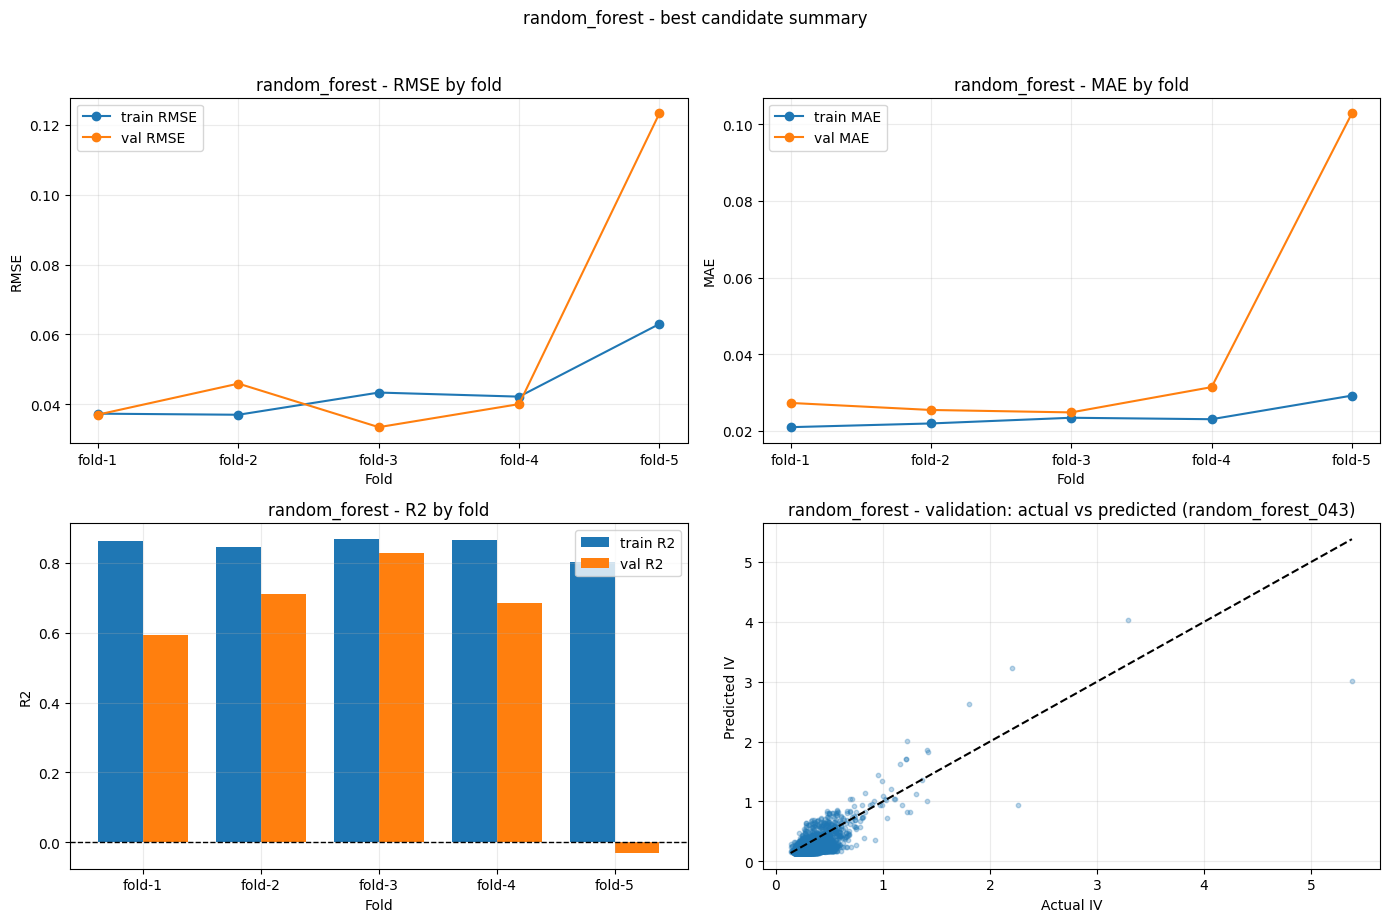

In [7]:
random_forest_models_metrics_table, random_forest_best_model_name = Trainer(RandomForestFamily).run_kfolds_training()

2026-05-17 15:39:18,619 | INFO | src.volatility_models.training_utils | Hyperparameter exploration for 'xgboost' (metadata cache): 200/102060000 configurations (0.00%).
2026-05-17 15:39:18,621 | INFO | src.volatility_models.visualization_utils | Metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\xgboost_metadata.json
2026-05-17 15:39:18,632 | INFO | src.volatility_models.visualization_utils | Showing top 15 family models
             custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
xgboost_118       0.068264   0.023407    0.047833  0.827437  0.041317  0.054675  0.575005       0.003137        0.011672      0.034128     0.029349      0.033830    0.302187
xgboost_019       0.068445   0.024024    0.050028  0.810989  0.041587  0.055640  0.559894       0.002920        0.011538      0.032298     0.

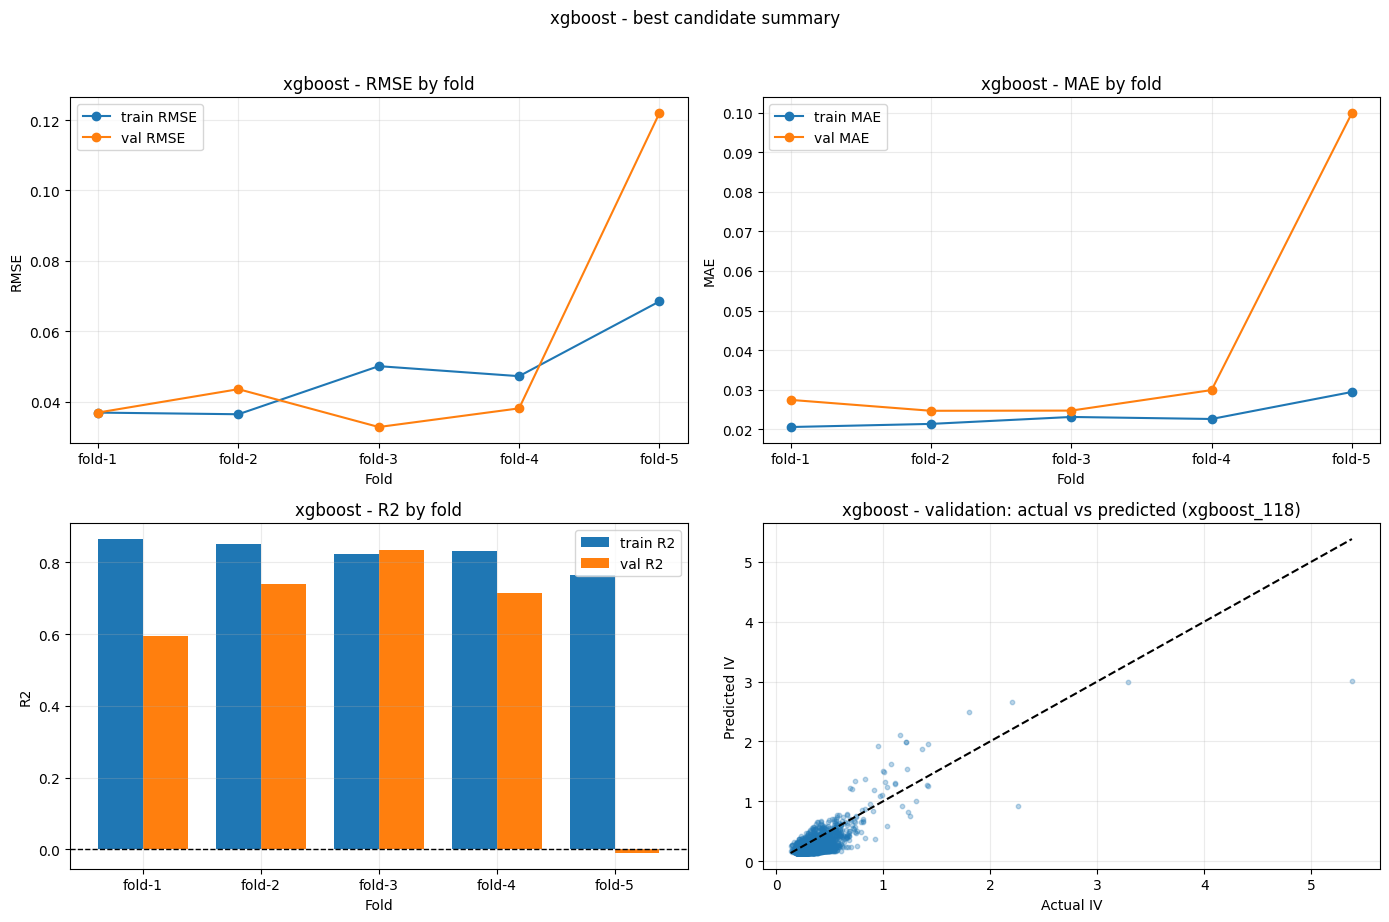

In [8]:
xgboost_models_metrics_table, xgboost_best_model_name = Trainer(XGBoostFamily).run_kfolds_training()

2026-05-17 15:39:29,281 | INFO | src.volatility_models.training_utils | Hyperparameter exploration for 'sequential_nn' (metadata cache): 120/400000 configurations (0.03%).
2026-05-17 15:39:29,281 | INFO | src.volatility_models.visualization_utils | Metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\sequential_nn_metadata.json
2026-05-17 15:39:29,292 | INFO | src.volatility_models.visualization_utils | Showing top 15 family models
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
sequential_nn_119       0.065313   0.027080    0.054305  0.774439  0.038963  0.056706  0.548535       0.006364        0.011647      0.041496     0.023283      0.027226    0.200623
sequential_nn_021       0.068137   0.023577    0.046011  0.838857  0.040958  0.053843  0.588384       0.003188        0.

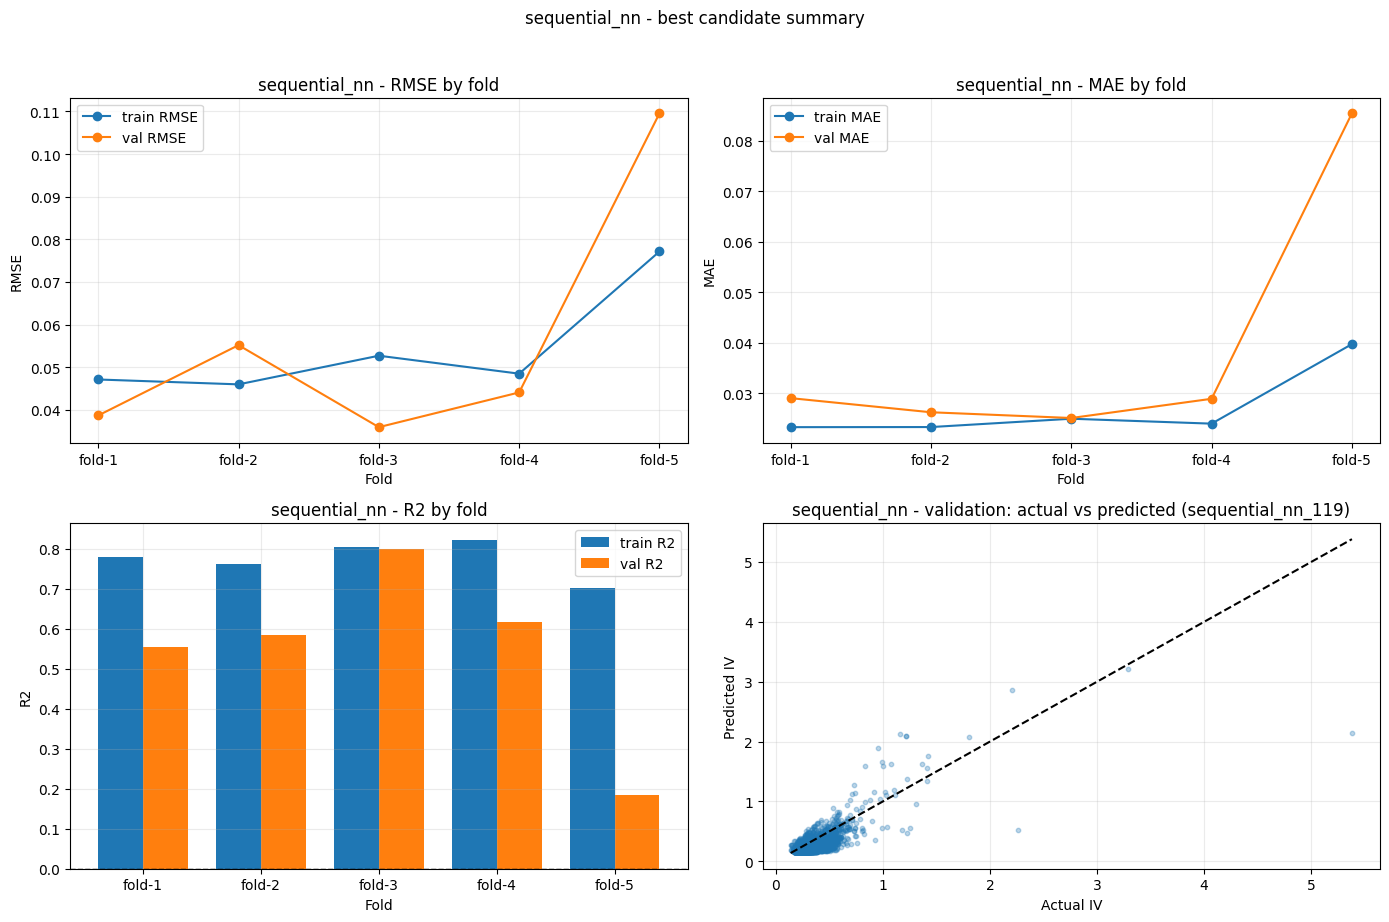

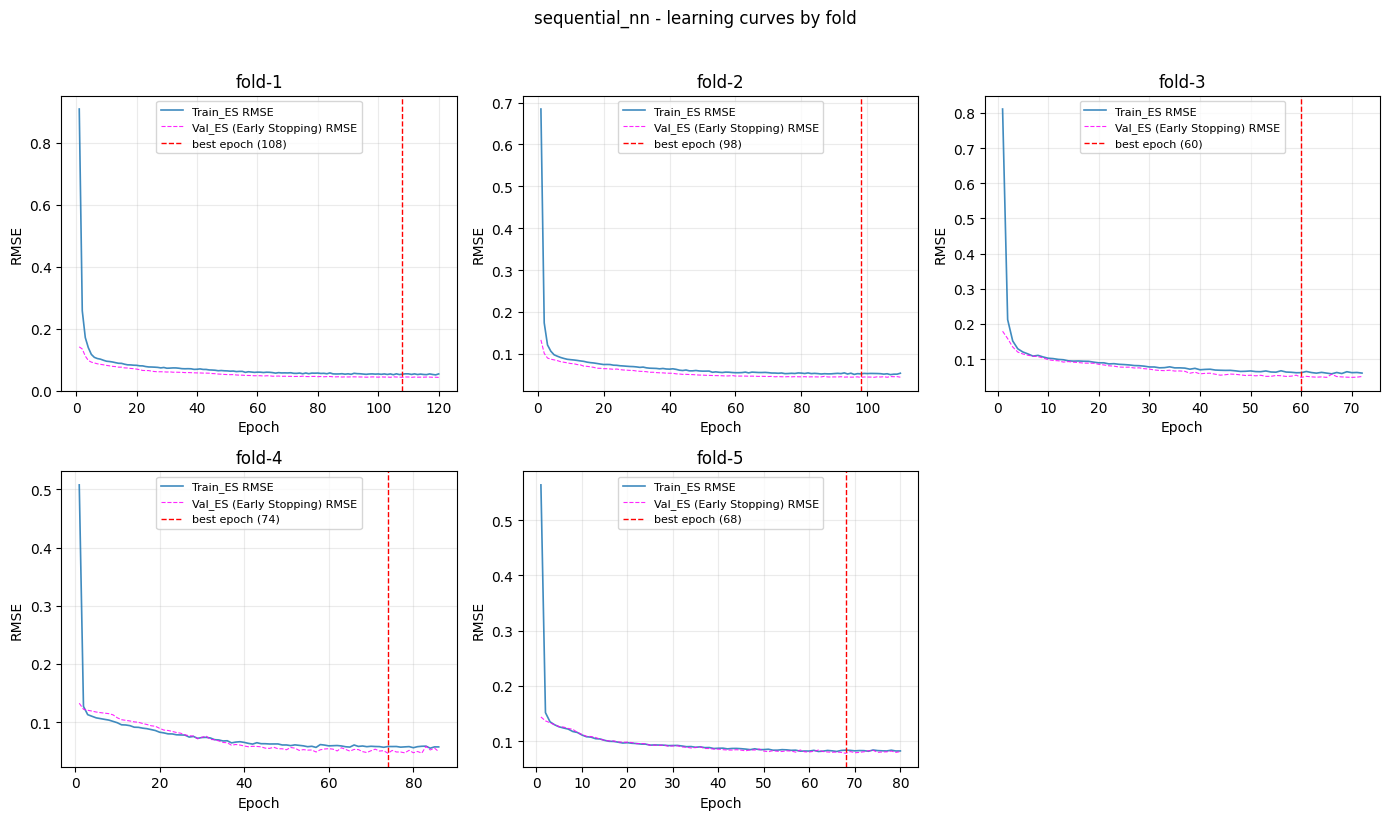

In [9]:
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training()

2026-05-17 15:39:34,875 | INFO | src.volatility_models.training_utils | Hyperparameter exploration for 'quantum_inspired_nn' (metadata cache): 50/51200 configurations (0.10%).
2026-05-17 15:39:34,875 | INFO | src.volatility_models.visualization_utils | Metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\quantum_inspired_nn_metadata.json
2026-05-17 15:39:34,911 | INFO | src.volatility_models.visualization_utils | Showing top 15 family models
                         custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
quantum_inspired_nn_039       0.070456   0.026325    0.052174  0.793918  0.041790  0.057867  0.527733       0.004738        0.013932      0.053079     0.027756      0.033278    0.297126
quantum_inspired_nn_050       0.070833   0.026023    0.048614  0.820098  0.040873  0.056922  0.547

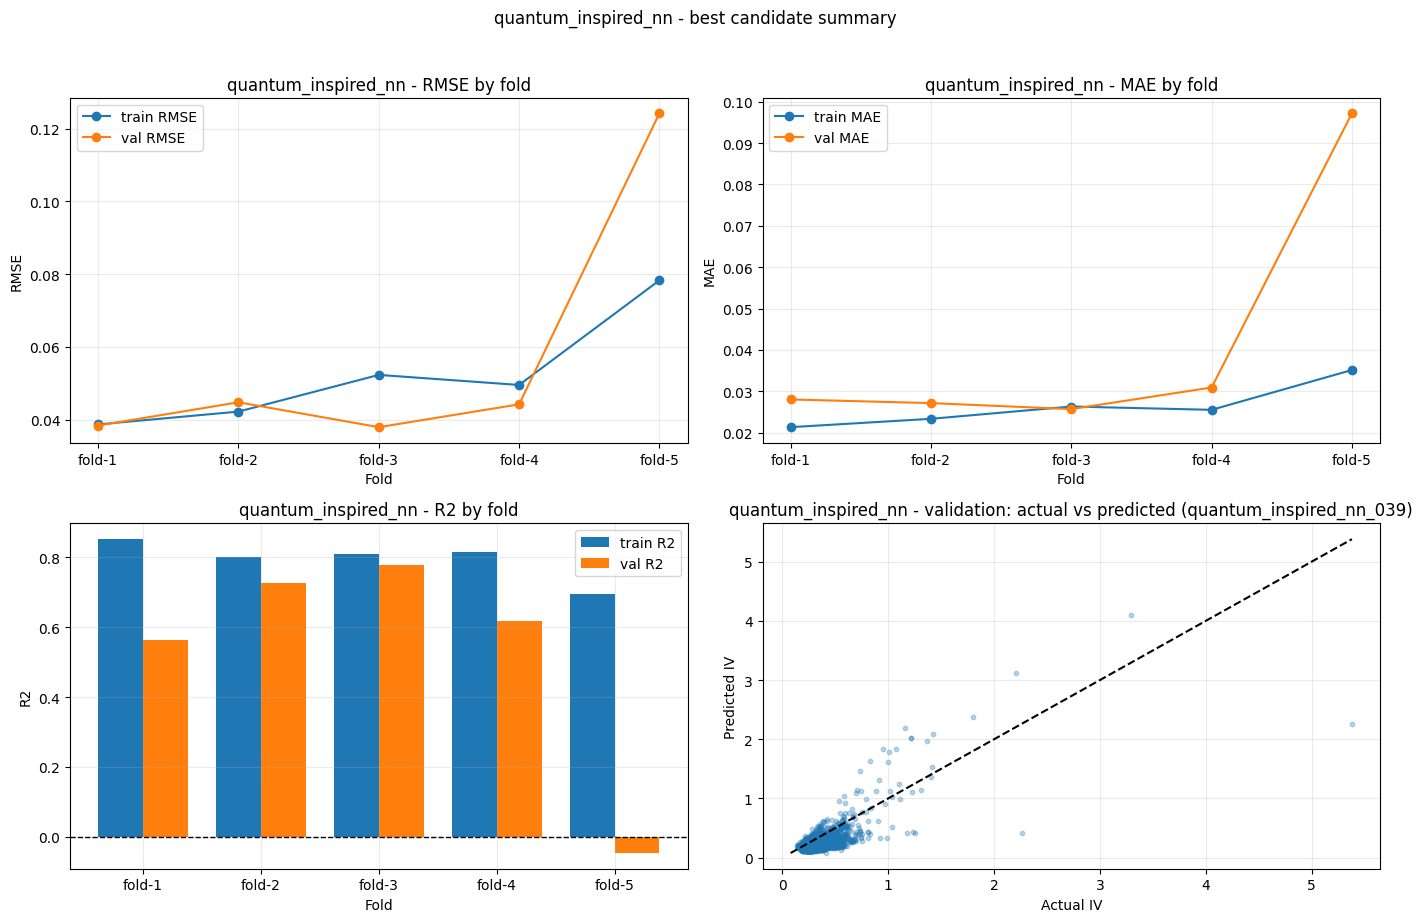

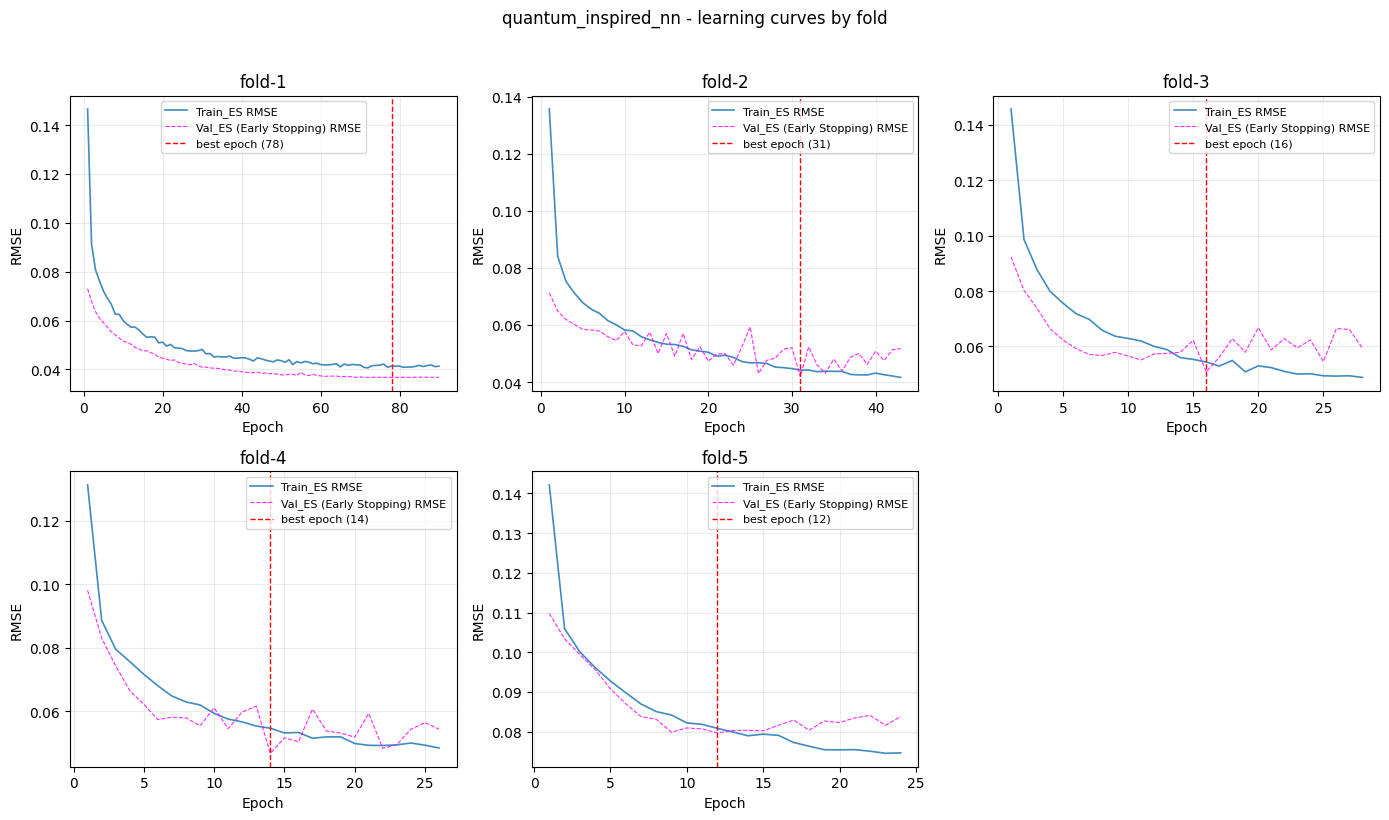

In [10]:
quantum_inspired_nn_models_metrics_table, quantum_inspired_nn_best_model_name = Trainer(QuantumInspiredNNFamily).run_kfolds_training()

# Fase 2: Reentrenamiento en TRAIN+VAL usando la mejor configuración de parámetros encontrada

In [11]:
linear_best_model_metrics = Trainer(LinearRegressionFamily).retrain_best_params_family()

2026-05-17 15:39:36,444 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\linear_regression_train_val_retrained_metadata.json
2026-05-17 15:39:36,448 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.133738   0.058647  0.045267    0.128955  0.109247  0.252617  0.181107
2026-05-17 15:39:36,450 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.074972, residual=0.128955 | val: real=0.120725, pred=0.060006, residual=0.108957


In [12]:
random_forest_best_model_metrics = Trainer(RandomForestFamily).retrain_best_params_family()

2026-05-17 15:39:36,482 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\random_forest_train_val_retrained_metadata.json
2026-05-17 15:39:36,485 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae  val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.089361   0.038083   0.0422    0.071027   0.07108  0.773269  0.653348
2026-05-17 15:39:36,486 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.122501, residual=0.071027 | val: real=0.120725, pred=0.085760, residual=0.067039


In [13]:
xgboost_best_model_metrics = Trainer(XGBoostFamily).retrain_best_params_family()

2026-05-17 15:39:36,522 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\xgboost_train_val_retrained_metadata.json
2026-05-17 15:39:36,523 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.086826   0.038344  0.042299    0.074724   0.06976  0.749049  0.666097
2026-05-17 15:39:36,528 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.114227, residual=0.074722 | val: real=0.120725, pred=0.085066, residual=0.065647


2026-05-17 15:39:36,565 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\sequential_nn_train_val_retrained_metadata.json
2026-05-17 15:39:36,572 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.090209   0.040467  0.037925    0.079183  0.073881  0.718206  0.625488
2026-05-17 15:39:36,572 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.120441, residual=0.079144 | val: real=0.120725, pred=0.073220, residual=0.071881


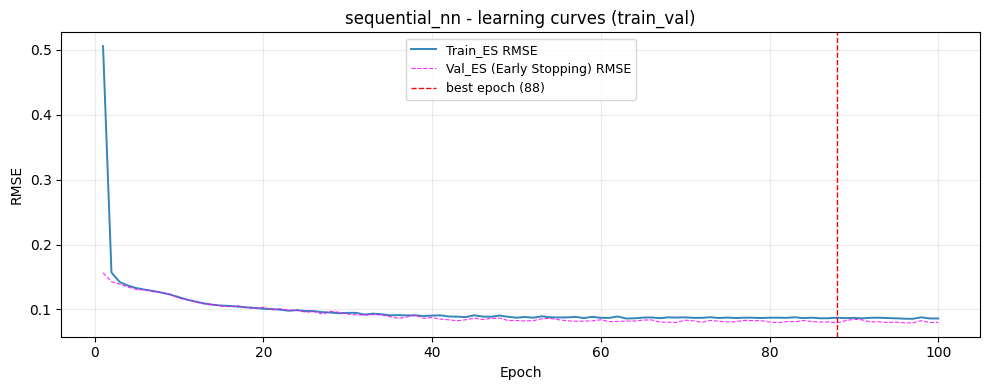

In [14]:
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family()

2026-05-17 15:39:36,815 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\quantum_inspired_nn_train_val_retrained_metadata.json
2026-05-17 15:39:36,821 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.089332    0.04238  0.038767    0.080321  0.071718   0.71005  0.647092
2026-05-17 15:39:36,822 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.128903, residual=0.080319 | val: real=0.120725, pred=0.080253, residual=0.069545


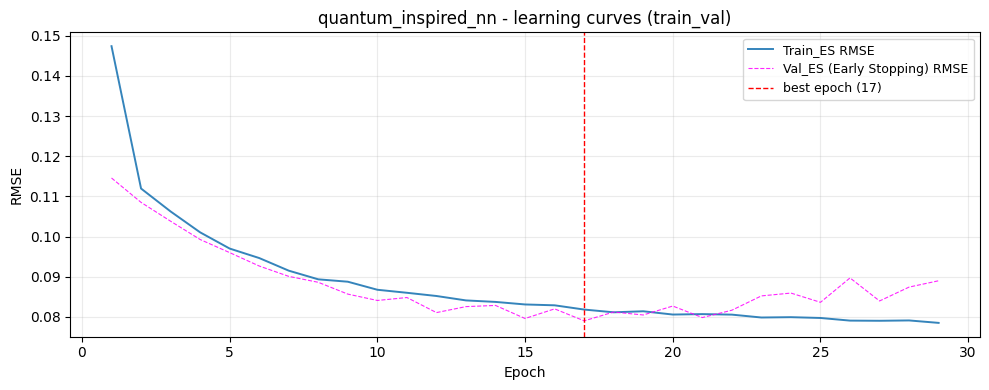

In [15]:
quantum_inspired_nn_best_model_metrics = Trainer(QuantumInspiredNNFamily).retrain_best_params_family()

# Fase 3: Evaluación del modelo reentrenado en FINAL_TEST

In [3]:
linear_best_model_metrics_test = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

2026-05-17 23:45:32,880 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-17 23:45:32,882 | INFO | src.volatility_models.training_utils | Training: Retraining 'linear_regression' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-17 23:45:33,002 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best      0.057062  0.067585       0.127747   0.183824       0.2478  0.096059
2026-05-17 23:45:33,004 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.073322, residual=0.127747 | test: real=0.193345, pred=0.049568, residual=0.179629
2026-05-17 23:45:33,108 | INFO | src.volatility_models.visualization_utils | Retraini

In [4]:
random_forest_best_model_metrics_test = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

2026-05-18 00:47:01,412 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 00:47:01,414 | INFO | src.volatility_models.training_utils | Training: Retraining 'random_forest' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 00:47:18,910 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best      0.037966  0.054366         0.0706   0.088403     0.770256  0.790941
2026-05-18 00:47:18,911 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.120195, residual=0.070600 | test: real=0.193345, pred=0.149458, residual=0.085859
2026-05-18 00:47:19,020 | INFO | src.volatility_models.visualization_utils | Retraining m

In [5]:
xgboost_best_model_metrics_test = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

2026-05-18 01:49:25,454 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 01:49:25,455 | INFO | src.volatility_models.training_utils | Training: Retraining 'xgboost' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 01:49:31,066 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2  test_r2
retrained_best      0.038138  0.054555        0.07433   0.091642     0.745343  0.77534
2026-05-18 01:49:31,067 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.112170, residual=0.074326 | test: real=0.193345, pred=0.139343, residual=0.088339
2026-05-18 01:49:31,216 | INFO | src.volatility_models.visualization_utils | Retraining metadata 

2026-05-18 02:51:19,396 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 02:51:19,398 | INFO | src.volatility_models.training_utils | Training: Retraining 'sequential_nn' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 02:52:55,336 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best      0.039746  0.056104       0.081065   0.122067     0.697101  0.601406
2026-05-18 02:52:55,336 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.106716, residual=0.080920 | test: real=0.193345, pred=0.100313, residual=0.117718


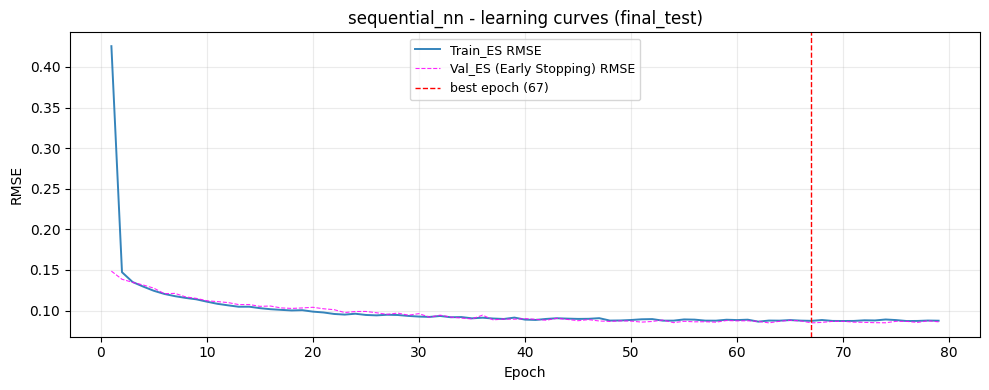

2026-05-18 02:52:55,584 | INFO | src.volatility_models.visualization_utils | Retraining metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\sequential_nn_final_test_retrained_metadata.json
2026-05-18 02:52:55,624 | INFO | src.volatility_models.visualization_utils | Scaler saved to: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\sequential_nn_scaler.joblib
2026-05-18 02:52:55,625 | INFO | src.volatility_models.visualization_utils | Model saved to: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\sequential_nn.keras
2026-05-18 03:54:21,782 | INFO | src.volatility_models.training_utils | model2dashboard pipeline for family 'sequential_nn' completed successfully.
2026-05-18 03:54:27,059 | INFO | src.volatility_models.training_utils | Trained model 'sequential_nn' uploaded to GCP: C:\Users\danir\Desktop\TFM - Opciones\options-prici

In [6]:
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

2026-05-18 03:54:42,663 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 03:54:42,665 | INFO | src.volatility_models.training_utils | Training: Retraining 'quantum_inspired_nn' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 03:56:37,236 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best      0.039862  0.056056       0.086745   0.143025     0.653167  0.452784
2026-05-18 03:56:37,237 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.130613, residual=0.086745 | test: real=0.193345, pred=0.167320, residual=0.141803


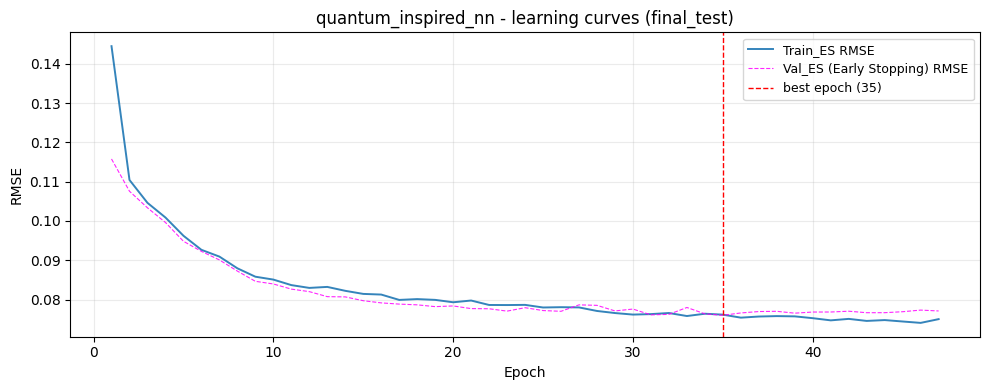

2026-05-18 03:56:37,402 | INFO | src.volatility_models.visualization_utils | Retraining metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\quantum_inspired_nn_final_test_retrained_metadata.json
2026-05-18 03:56:37,472 | INFO | src.volatility_models.visualization_utils | Scaler saved to: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\quantum_inspired_nn_scaler.joblib
2026-05-18 03:56:37,473 | INFO | src.volatility_models.visualization_utils | Model saved to: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\quantum_inspired_nn.keras
2026-05-18 04:58:34,919 | INFO | src.volatility_models.training_utils | model2dashboard pipeline for family 'quantum_inspired_nn' completed successfully.
2026-05-18 04:58:39,624 | INFO | src.volatility_models.training_utils | Trained model 'quantum_inspired_nn' uploaded to GCP: C:\Users\danir\Deskto

In [7]:
quantum_inspired_nn_best_model_metrics_test = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=True)

# Fase 4: Reentrenamiento progresivo en TRAIN+VAL (priorizando datos ATM) con la mejor configuración de parámetros

In [21]:
linear_best_model_metrics_progressive = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

2026-05-17 15:39:37,821 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\linear_regression_retrained_progressive_train_val_retrained_metadata.json
2026-05-17 15:39:37,828 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2   val_r2
retrained_best       0.132802   0.054729  0.041483    0.129818  0.108311  0.242578  0.19509
2026-05-17 15:39:37,828 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.070924, residual=0.129608 | val: real=0.120725, pred=0.059494, residual=0.108293


In [22]:
random_forest_best_model_metrics_progressive = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

2026-05-17 15:39:37,875 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\random_forest_retrained_progressive_train_val_retrained_metadata.json
2026-05-17 15:39:37,878 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae  val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.091597   0.038162  0.04178     0.07173  0.072659  0.768756  0.637774
2026-05-17 15:39:37,880 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.121352, residual=0.071722 | val: real=0.120725, pred=0.084580, residual=0.068887


In [23]:
xgboost_best_model_metrics_progressive = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

2026-05-17 15:39:37,911 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\xgboost_retrained_progressive_train_val_retrained_metadata.json
2026-05-17 15:39:37,922 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.093189   0.039671  0.039348    0.086577  0.076123  0.663126  0.602407
2026-05-17 15:39:37,922 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.089502, residual=0.086407 | val: real=0.120725, pred=0.067092, residual=0.073836


2026-05-17 15:39:37,965 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\sequential_nn_retrained_progressive_train_val_retrained_metadata.json
2026-05-17 15:39:37,968 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.096304   0.041406  0.041311    0.083194  0.079976  0.688933  0.561139
2026-05-17 15:39:37,968 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.107249, residual=0.083161 | val: real=0.120725, pred=0.080151, residual=0.076279


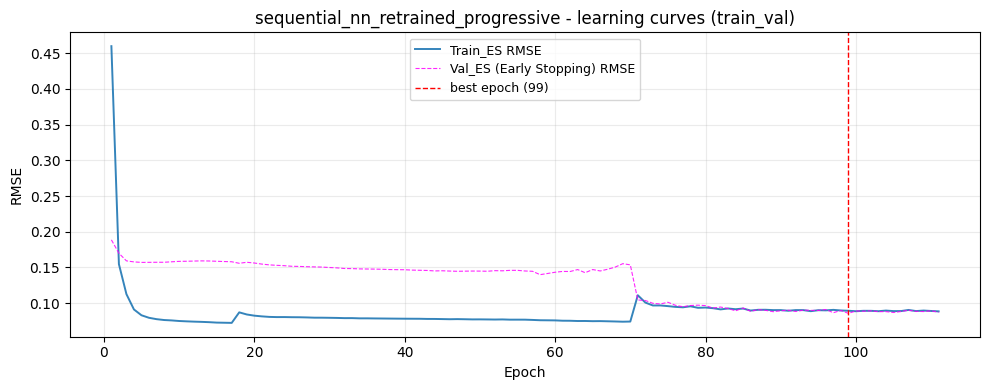

In [24]:
sequential_nn_best_model_metrics_progressive = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

2026-05-17 15:39:38,433 | INFO | src.volatility_models.visualization_utils | Retraining metadata loaded from cache: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\quantum_inspired_nn_retrained_progressive_train_val_retrained_metadata.json
2026-05-17 15:39:38,442 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining:
                custom_error2  train_mae   val_mae  train_rmse  val_rmse  train_r2    val_r2
retrained_best       0.100256   0.043564  0.042185    0.085862  0.082642  0.668667  0.531394
2026-05-17 15:39:38,443 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: train: real=0.149165, pred=0.115967, residual=0.085861 | val: real=0.120725, pred=0.070842, residual=0.079648


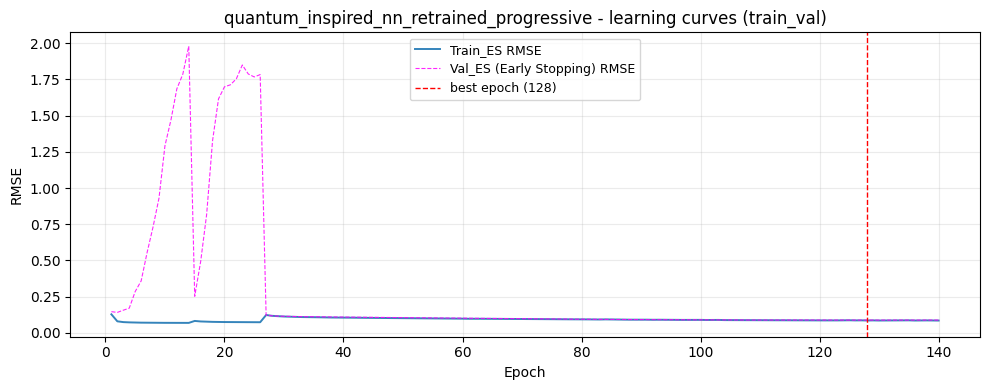

In [25]:
quantum_inspired_nn_best_model_metrics_progressive = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.TRAIN_VAL, progressive_training=True)

# Fase 5: Evaluación del modelo progresivo en FINAL_TEST

In [8]:
linear_best_model_metrics_test_progressive = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=False, progressive_training=True)

2026-05-18 04:58:53,011 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 04:58:53,013 | INFO | src.volatility_models.training_utils | Progressive training: Retraining 'linear_regression_retrained_progressive' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 04:58:53,098 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best       0.05338  0.070544       0.128545   0.187747     0.238379  0.057069
2026-05-18 04:58:53,098 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.069767, residual=0.128348 | test: real=0.193345, pred=0.047441, residual=0.181265
2026-05-18 04:58:53,172 | INFO | src.volatility_mod

In [9]:
random_forest_best_model_metrics_test_progressive = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=False, progressive_training=True)

2026-05-18 05:59:36,439 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 05:59:36,441 | INFO | src.volatility_models.training_utils | Progressive training: Retraining 'random_forest_retrained_progressive' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 05:59:52,816 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best      0.037965  0.054337       0.071128   0.088533     0.766808  0.790326
2026-05-18 05:59:52,817 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.119310, residual=0.071119 | test: real=0.193345, pred=0.149229, residual=0.085621
2026-05-18 05:59:52,913 | INFO | src.volatility_models.

In [10]:
xgboost_best_model_metrics_test_progressive = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=False, progressive_training=True)

2026-05-18 07:01:01,395 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 07:01:01,398 | INFO | src.volatility_models.training_utils | Progressive training: Retraining 'xgboost_retrained_progressive' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 07:01:05,712 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best      0.039343  0.057309       0.085072   0.113296     0.666419  0.656626
2026-05-18 07:01:05,714 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.088736, residual=0.084894 | test: real=0.193345, pred=0.104298, residual=0.108179
2026-05-18 07:01:05,863 | INFO | src.volatility_models.visual

2026-05-18 08:01:59,962 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 08:01:59,964 | INFO | src.volatility_models.training_utils | Progressive training: Retraining 'sequential_nn_retrained_progressive' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 08:04:21,718 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best      0.040449  0.055372       0.080822   0.120108     0.698914  0.614095
2026-05-18 08:04:21,719 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.109152, residual=0.080805 | test: real=0.193345, pred=0.100324, residual=0.116613


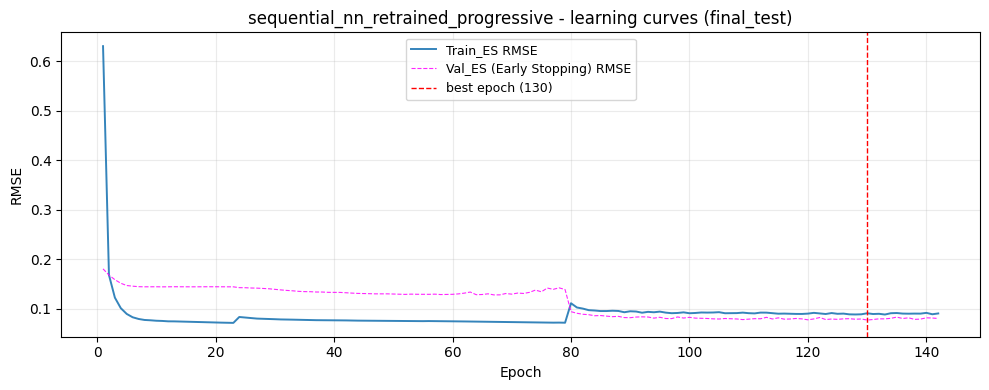

2026-05-18 08:04:21,896 | INFO | src.volatility_models.visualization_utils | Retraining metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\sequential_nn_retrained_progressive_final_test_retrained_metadata.json
2026-05-18 08:04:21,928 | INFO | src.volatility_models.visualization_utils | Scaler saved to: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\sequential_nn_retrained_progressive_scaler.joblib
2026-05-18 08:04:21,929 | INFO | src.volatility_models.visualization_utils | Model saved to: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\sequential_nn_retrained_progressive.keras
2026-05-18 09:05:46,413 | INFO | src.volatility_models.training_utils | model2dashboard pipeline for family 'sequential_nn_retrained_progressive' completed successfully.


In [11]:
sequential_nn_best_model_metrics_test_progressive = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=False, progressive_training=True)

2026-05-18 09:05:52,126 | INFO | src.volatility_models.data_utils | Final split | rows: trainval=273223 [2017-01-02 -> 2021-08-10]  test=36973 [2021-09-01 -> 2022-06-28]  total=310196
2026-05-18 09:05:52,128 | INFO | src.volatility_models.training_utils | Progressive training: Retraining 'quantum_inspired_nn_retrained_progressive' | phase=final_test | input fit: train_rows=273223 eval_rows=36973 total_rows=310196
2026-05-18 09:12:17,874 | INFO | src.volatility_models.visualization_utils | Best family model results after retraining on train + val:
                trainval_mae  test_mae  trainval_rmse  test_rmse  trainval_r2   test_r2
retrained_best       0.04215  0.055597       0.083329   0.117404     0.679945  0.631276
2026-05-18 09:12:17,874 | INFO | src.volatility_models.visualization_utils | Volatility Dispersion Summary: trainval: real=0.147294, pred=0.119235, residual=0.083329 | test: real=0.193345, pred=0.105575, residual=0.115262


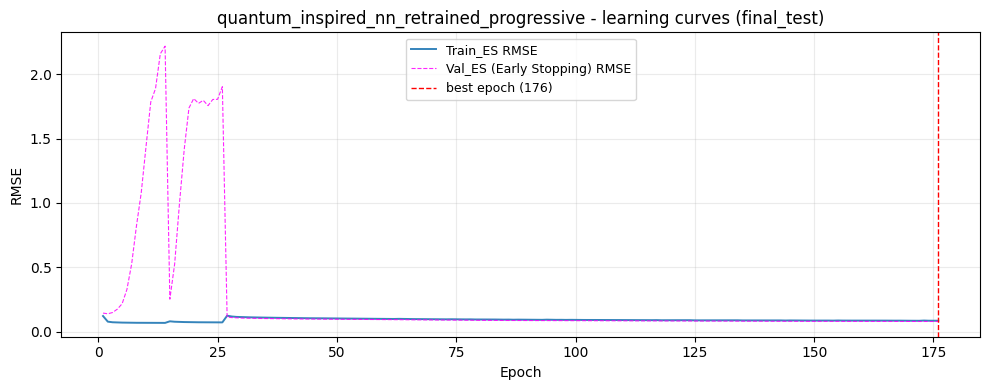

2026-05-18 09:12:18,042 | INFO | src.volatility_models.visualization_utils | Retraining metadata saved: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\quantum_inspired_nn_retrained_progressive_final_test_retrained_metadata.json
2026-05-18 09:12:18,114 | INFO | src.volatility_models.visualization_utils | Scaler saved to: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\quantum_inspired_nn_retrained_progressive_scaler.joblib
2026-05-18 09:12:18,115 | INFO | src.volatility_models.visualization_utils | Model saved to: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\quantum_inspired_nn_retrained_progressive.keras
2026-05-18 10:14:19,961 | INFO | src.volatility_models.training_utils | model2dashboard pipeline for family 'quantum_inspired_nn_retrained_progressive' completed successfully.


In [12]:
quantum_inspired_nn_best_model_metrics_test_progressive = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, upload_to_gcp=False, progressive_training=True)